# K-Nearest Neighbors (KNN) - Telco Customer Churn

Predicting customer churn using KNN with advanced techniques: SMOTE, PCA, ROC/AUC, decision boundaries, and permutation importance.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
%matplotlib inline

---
## 1. Load & Clean Data

In [19]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Shape after cleaning:', df.shape)

Shape after cleaning: (7032, 20)


In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print('Encoded shape:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Class balance — Train: {y_train.value_counts().to_dict()}')
print(f'             Test:  {y_test.value_counts().to_dict()}')

Encoded shape: (7032, 30)
Train: 4922, Test: 2110
Class balance — Train: {0: 3614, 1: 1308}
             Test:  {0: 1549, 1: 561}


In [22]:
scaler = preprocessing.StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

---
## 2. Baseline KNN (k=5)

In [23]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_s, y_train)
y_pred5 = knn5.predict(X_test_s)

print('Baseline KNN (k=5):')
print('Accuracy:', metrics.accuracy_score(y_test, y_pred5))
print('Precision:', metrics.precision_score(y_test, y_pred5))
print('Recall:', metrics.recall_score(y_test, y_pred5))
print('F1-score:', metrics.f1_score(y_test, y_pred5))
print()
print('Confusion Matrix:')
print(metrics.confusion_matrix(y_test, y_pred5))

Baseline KNN (k=5):
Accuracy: 0.7459715639810427
Precision: 0.5225225225225225
Recall: 0.5169340463458111
F1-score: 0.5197132616487455

Confusion Matrix:
[[1284  265]
 [ 271  290]]


---
## 3. GridSearchCV with SMOTE (Class Imbalance Handling)

SMOTE oversamples the minority class (churners) to improve recall. We use `imblearn.pipeline.Pipeline` so SMOTE is applied only inside each CV fold (no data leakage).

In [24]:
param_grid = {
    'knn__n_neighbors': range(1, 31),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid = GridSearchCV(
    pipe, param_grid, cv=StratifiedKFold(5),
    scoring='recall', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f'\nBest params: {grid.best_params_}')
print(f'Best CV recall: {grid.best_score_:.4f}')

Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
Best CV recall: 0.7874


In [25]:
y_pred_smote = grid.predict(X_test)

print('KNN + SMOTE (tuned for recall):')
print('Accuracy:', metrics.accuracy_score(y_test, y_pred_smote))
print('Precision:', metrics.precision_score(y_test, y_pred_smote))
print('Recall:', metrics.recall_score(y_test, y_pred_smote))
print('F1-score:', metrics.f1_score(y_test, y_pred_smote))
print()
print('Confusion Matrix:')
print(metrics.confusion_matrix(y_test, y_pred_smote))
print()
print('Recall improved vs baseline:',
      f'{metrics.recall_score(y_test, y_pred_smote) - metrics.recall_score(y_test, y_pred5):.3f}')

KNN + SMOTE (tuned for recall):
Accuracy: 0.7061611374407583
Precision: 0.46884899683210135
Recall: 0.7914438502673797
F1-score: 0.5888594164456233

Confusion Matrix:
[[1046  503]
 [ 117  444]]

Recall improved vs baseline: 0.275


---
## 4. GridSearchCV Results (without SMOTE, scoring=accuracy)

In [26]:
grid_acc = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan', 'minkowski']},
    cv=StratifiedKFold(5), scoring='accuracy', n_jobs=-1, verbose=1
)
grid_acc.fit(X_train_s, y_train)

print(f'Best params: {grid_acc.best_params_}')
print(f'Best CV accuracy: {grid_acc.best_score_:.4f}')
print(f'Test accuracy: {grid_acc.score(X_test_s, y_test):.4f}')

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'uniform'}
Best CV accuracy: 0.7944
Test accuracy: 0.7844


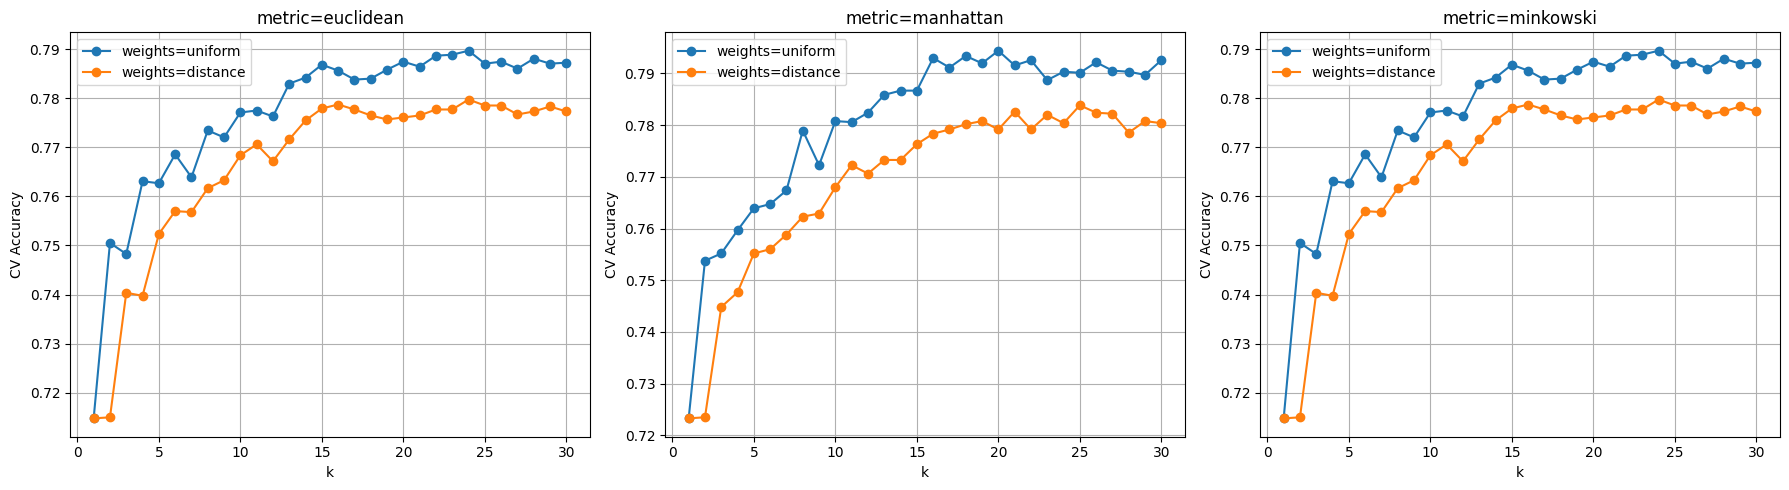

In [27]:
results = pd.DataFrame(grid_acc.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, metric in enumerate(['euclidean', 'manhattan', 'minkowski']):
    ax = axes[idx]
    for w in ['uniform', 'distance']:
        mask = (results['param_metric'] == metric) & (results['param_weights'] == w)
        sub = results[mask].sort_values('param_n_neighbors')
        ax.plot(sub['param_n_neighbors'].astype(int), sub['mean_test_score'],
                marker='o', label=f'weights={w}')
    ax.set_title(f'metric={metric}')
    ax.set_xlabel('k')
    ax.set_ylabel('CV Accuracy')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

---
## 5. PCA — Dimensionality Reduction & Accuracy Comparison

We apply PCA and compare KNN accuracy across different component counts vs the full 30-feature set.

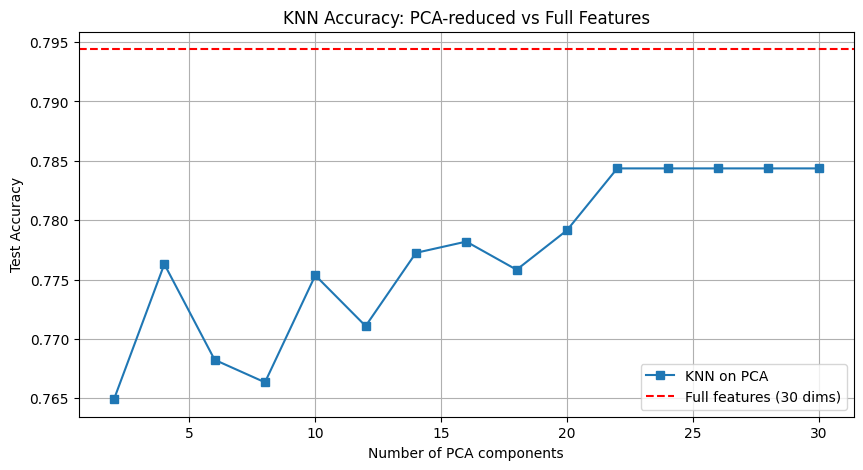

In [28]:
best_k = grid_acc.best_params_['n_neighbors']
best_w = grid_acc.best_params_['weights']
best_m = grid_acc.best_params_['metric']
full_acc = grid_acc.best_score_

n_components_range = range(2, 31, 2)
pca_scores = []

for n in n_components_range:
    pca = PCA(n_components=n, random_state=42)
    X_pca = pca.fit_transform(X_train_s)
    knn = KNeighborsClassifier(n_neighbors=best_k, weights=best_w, metric=best_m)
    knn.fit(X_pca, y_train)
    X_test_pca = pca.transform(X_test_s)
    acc = metrics.accuracy_score(y_test, knn.predict(X_test_pca))
    pca_scores.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, pca_scores, marker='s', label='KNN on PCA')
plt.axhline(y=full_acc, color='r', linestyle='--', label=f'Full features ({X.shape[1]} dims)')
plt.xlabel('Number of PCA components')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy: PCA-reduced vs Full Features')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
best_pca_n = n_components_range[np.argmax(pca_scores)]
best_pca_acc = max(pca_scores)
print(f'Best PCA components: {best_pca_n} (accuracy: {best_pca_acc:.4f})')
print(f'Full features accuracy: {full_acc:.4f}')
print(f'Difference: {best_pca_acc - full_acc:+.4f}')

Best PCA components: 22 (accuracy: 0.7844)
Full features accuracy: 0.7944
Difference: -0.0100


---
## 6. ROC Curve & AUC

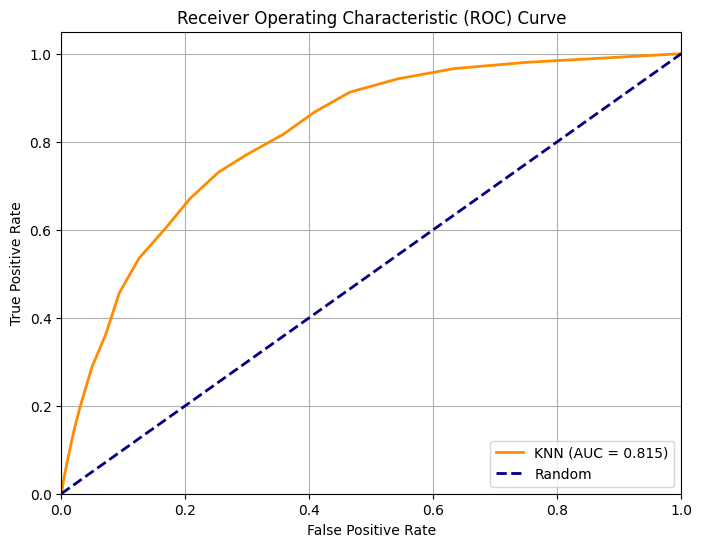

AUC: 0.8149


In [30]:
best_knn = grid_acc.best_estimator_
y_prob = best_knn.predict_proba(X_test_s)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'KNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'AUC: {roc_auc:.4f}')

---
## 7. Decision Boundary (PCA 2D Projection)

We project data to 2D with PCA and visualize how KNN partitions the space.

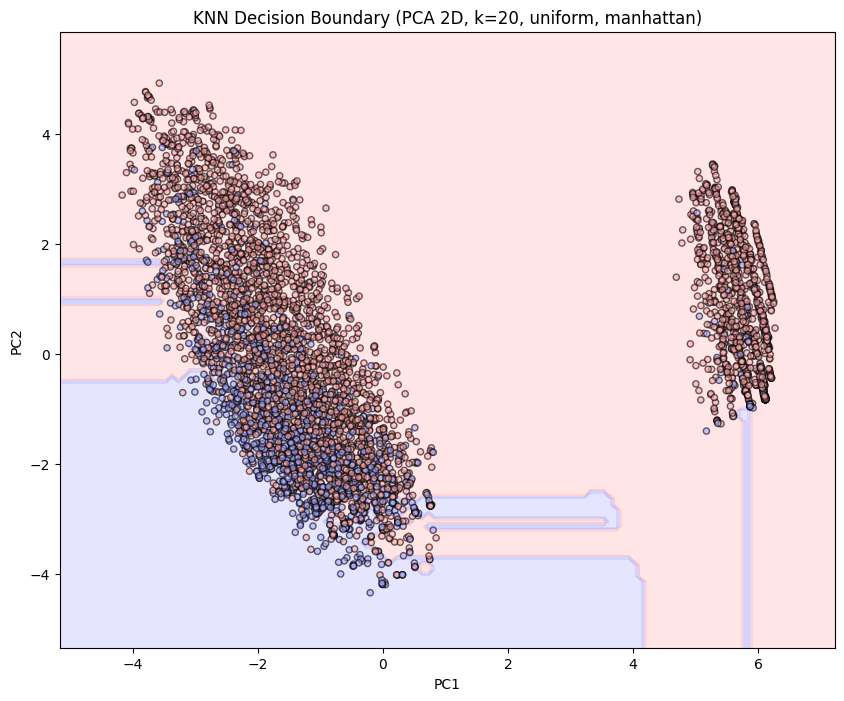

Explained variance ratio: PC1=0.332, PC2=0.120
Total explained: 0.453


In [31]:
pca2 = PCA(n_components=2, random_state=42)
X_train_2d = pca2.fit_transform(X_train_s)
X_test_2d = pca2.transform(X_test_s)

knn_2d = KNeighborsClassifier(n_neighbors=best_k, weights=best_w, metric=best_m)
knn_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

colors = ListedColormap(['#FFAAAA', '#AAAAFF'])
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=colors)
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
            c=y_train, cmap=colors, edgecolor='k', s=20, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KNN Decision Boundary (PCA 2D, k={best_k}, {best_w}, {best_m})')
plt.show()

print(f'Explained variance ratio: PC1={pca2.explained_variance_ratio_[0]:.3f}, PC2={pca2.explained_variance_ratio_[1]:.3f}')
print(f'Total explained: {pca2.explained_variance_ratio_.sum():.3f}')

---
## 8. Permutation Feature Importance

Shuffle each feature and measure the drop in accuracy to determine which features matter most for KNN.

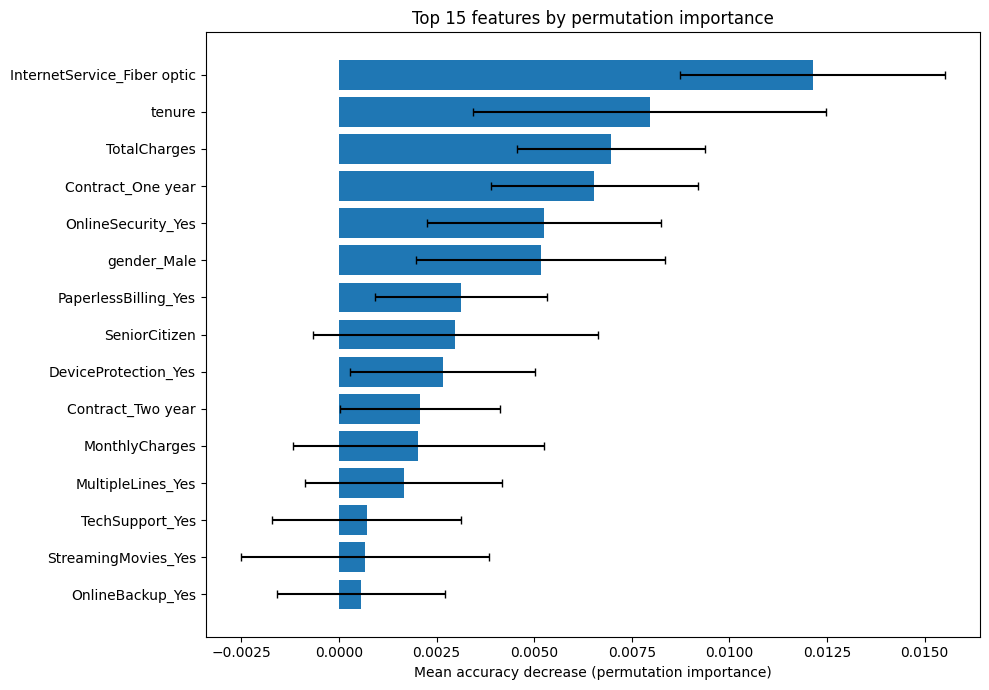

,feature,importance,std
10,InternetService_Fiber optic,0.012133,0.003386
1,tenure,0.007962,0.004515
3,TotalCharges,0.006967,0.002398
24,Contract_One year,0.006540,0.002654
13,OnlineSecurity_Yes,0.005261,0.003001
4,gender_Male,0.005166,0.003189
26,PaperlessBilling_Yes,0.003128,0.002194
0,SeniorCitizen,0.002986,0.003653
17,DeviceProtection_Yes,0.002654,0.002381
25,Contract_Two year,0.002085,0.002046


In [32]:
result = permutation_importance(
    best_knn, X_test_s, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

top_n = 15
top = importance_df.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(range(len(top)), top['importance'], xerr=top['std'], capsize=3)
plt.yticks(range(len(top)), top['feature'])
plt.xlabel('Mean accuracy decrease (permutation importance)')
plt.title(f'Top {top_n} features by permutation importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importance_df.head(10)

---
## Summary

In [33]:
print('=' * 55)
print('KNN PIPELINE SUMMARY')
print('=' * 55)
print(f'Dataset: Telco Customer Churn ({len(df)} samples, {X.shape[1]} features)')
print()
print('--- Baseline (k=5) ---')
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred5):.4f}')
print(f'Recall:   {metrics.recall_score(y_test, y_pred5):.4f}')
print()
print('--- GridSearchCV (no SMOTE) ---')
print(f'Best params: {grid_acc.best_params_}')
print(f'CV accuracy: {grid_acc.best_score_:.4f}')
print(f'Test accuracy: {grid_acc.score(X_test_s, y_test):.4f}')
print()
print('--- GridSearchCV + SMOTE (scored on recall) ---')
print(f'Best params: {grid.best_params_}')
print(f'Test recall: {metrics.recall_score(y_test, y_pred_smote):.4f}')
print()
print('--- PCA ---')
print(f'Best PCA accuracy: {best_pca_acc:.4f} with {best_pca_n} components')
print(f'Full features:     {full_acc:.4f}')
print()
print('--- ROC ---')
print(f'AUC: {roc_auc:.4f}')
print()
print('--- Top 5 features ---')
for i, row in importance_df.head(5).iterrows():
    print(f'  {row["feature"]:35s} {row["importance"]:.4f}')

KNN PIPELINE SUMMARY
Dataset: Telco Customer Churn (7032 samples, 30 features)

--- Baseline (k=5) ---
Accuracy: 0.7460
Recall:   0.5169

--- GridSearchCV (no SMOTE) ---
Best params: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'uniform'}
CV accuracy: 0.7944
Test accuracy: 0.7844

--- GridSearchCV + SMOTE (scored on recall) ---
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
Test recall: 0.7914

--- PCA ---
Best PCA accuracy: 0.7844 with 22 components
Full features:     0.7944

--- ROC ---
AUC: 0.8149

--- Top 5 features ---
  InternetService_Fiber optic         0.0121
  tenure                              0.0080
  TotalCharges                        0.0070
  Contract_One year                   0.0065
  OnlineSecurity_Yes                  0.0053
